<span style="color:#888888">Copyright (c) 2014-2021 National Technology and Engineering Solutions of Sandia, LLC. Under the terms of Contract DE-NA0003525 with National Technology and Engineering Solutions of Sandia, LLC, the U.S. Government retains certain rights in this software.     Redistribution and use in source and binary forms, with or without modification, are permitted provided that the following conditions are met:</span>

<span style="color:#888888">1. Redistributions of source code must retain the above copyright notice, this list of conditions and the following disclaimer.</span>

<span style="color:#888888">2. Redistributions in binary form must reproduce the above copyright notice, this list of conditions and the following disclaimer in the documentation and/or other materials provided with the distribution.</span>

<span style="color:#888888">THIS SOFTWARE IS PROVIDED BY THE COPYRIGHT HOLDERS AND CONTRIBUTORS "AS IS" AND ANY EXPRESS OR IMPLIED WARRANTIES, INCLUDING, BUT NOT LIMITED TO, THE IMPLIED WARRANTIES OF MERCHANTABILITY AND FITNESS FOR A PARTICULAR PURPOSE ARE DISCLAIMED. IN NO EVENT SHALL THE COPYRIGHT HOLDER OR CONTRIBUTORS BE LIABLE FOR ANY DIRECT, INDIRECT, INCIDENTAL, SPECIAL, EXEMPLARY, OR CONSEQUENTIAL DAMAGES (INCLUDING, BUT NOT LIMITED TO, PROCUREMENT OF SUBSTITUTE GOODS OR SERVICES; LOSS OF USE, DATA, OR PROFITS; OR BUSINESS INTERRUPTION) HOWEVER CAUSED AND ON ANY THEORY OF LIABILITY, WHETHER IN CONTRACT, STRICT LIABILITY, OR TORT (INCLUDING NEGLIGENCE OR OTHERWISE) ARISING IN ANY WAY OUT OF THE USE OF THIS SOFTWARE, EVEN IF ADVISED OF THE POSSIBILITY OF SUCH DAMAGE.</span>

## <span style="color:#0054a8">**Tutorial 5-D:**</span> <span style="color:#555555">Trajectory Visualization For Print</span>

In [1]:
# TODO: Clean up this Tutorial to make the others

**Purpose:** Generate trajectory images that are specifically designed for a paper/report

In [2]:
#This notebook demonstrates plotting trajectory figures for use in printed media / papers.

from tracktable.domain.terrestrial import TrajectoryPointReader
from tracktable.applications.assemble_trajectories import AssembleTrajectoryFromPoints
from tracktable.render.render_trajectories import render_trajectories_for_print
from tracktable.render.render_trajectories import render_trajectories_for_print_using_tiles
#from tracktable.algorithms.dbscan import compute_cluster_labels
from tracktable.core import data_directory
from datetime import timedelta
import cartopy
import cartopy.crs
import os.path

data_filename = os.path.join(data_directory(), 'SampleFlightsUS.csv')
inFile = open(data_filename, 'r')
reader = TrajectoryPointReader()
reader.input = inFile
reader.comment_character = '#'
reader.field_delimiter = ','
reader.object_id_column = 0
reader.timestamp_column = 1
reader.coordinates[0] = 2
reader.coordinates[1] = 3

builder = AssembleTrajectoryFromPoints()
builder.input = reader
builder.minimum_length = 5
builder.separation_time = timedelta(minutes=10)

all_trajectories = list(builder)


INFO:tracktable.applications.assemble_trajectoriesAssembleTrajectoryFromPoints:New trajectories will be declared after a separation of None distance units between two points or a time lapse of at least 0:10:00 (hours, minutes, seconds).
INFO:tracktable.applications.assemble_trajectoriesAssembleTrajectoryFromPoints:Trajectories with fewer than 5 points will be discarded.
INFO:tracktable.applications.assemble_trajectoriesAssembleTrajectoryFromPoints:Done assembling trajectories. 30 trajectories produced and 1 discarded for having fewer than 5 points.


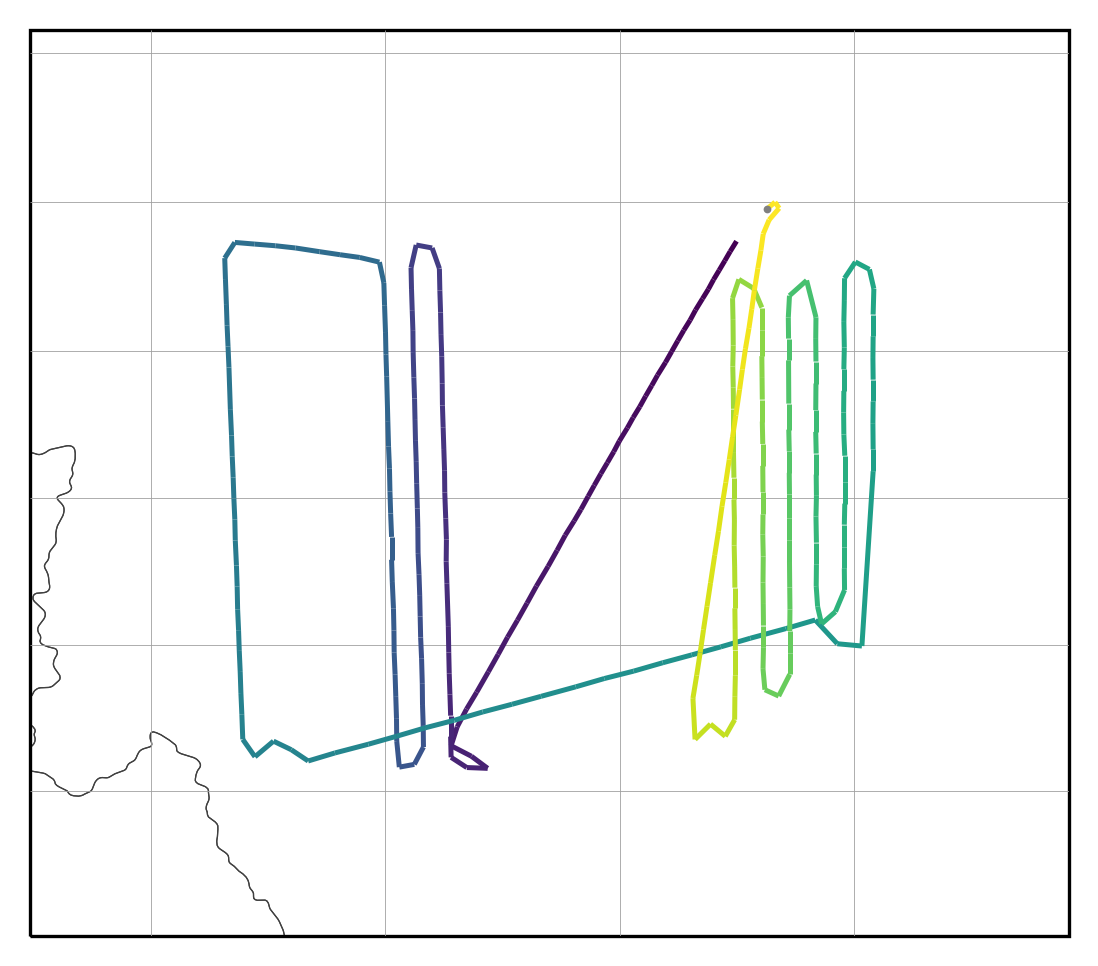

In [3]:
# Default behavior:
# Give it a list of trajectories and a filename.  Extension can be png, pdf, etc and it will output in correct format.
render_trajectories_for_print(all_trajectories[0], "myfig0.pdf")

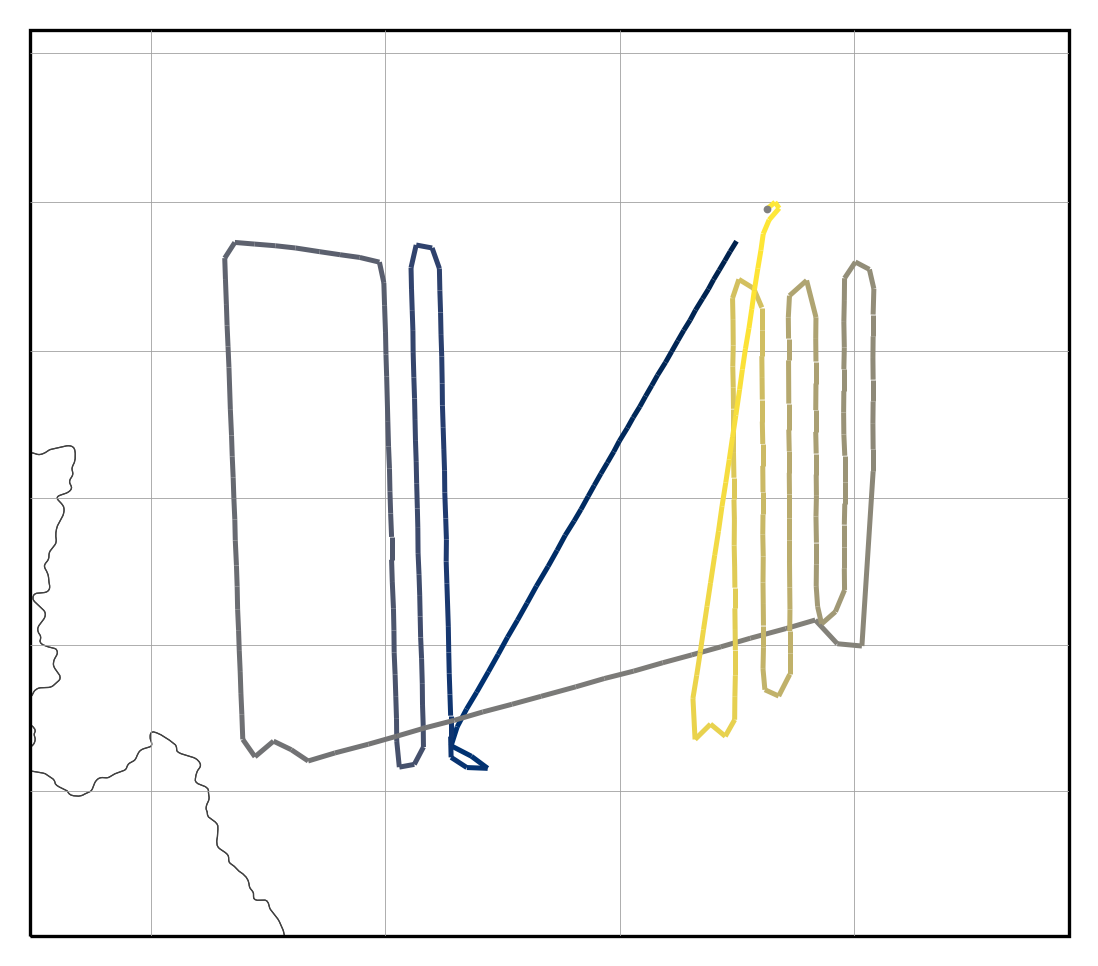

In [4]:
#can change colormap to any supported by matplotlib.  We recommend default (viridis) or this one (cividis)
render_trajectories_for_print(all_trajectories[0], "myfig0.png", color_map='cividis')

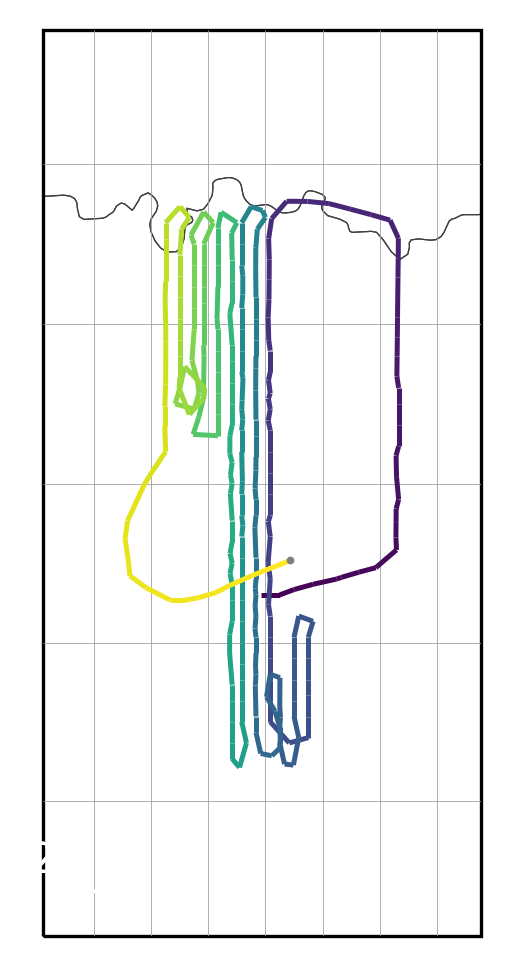

In [5]:
#Depending on your track(s) you may need to adjust linewidth until it's wide enough to see well, but not too thick.
render_trajectories_for_print(all_trajectories[1], "myfig1.pdf", linewidth=1.5)

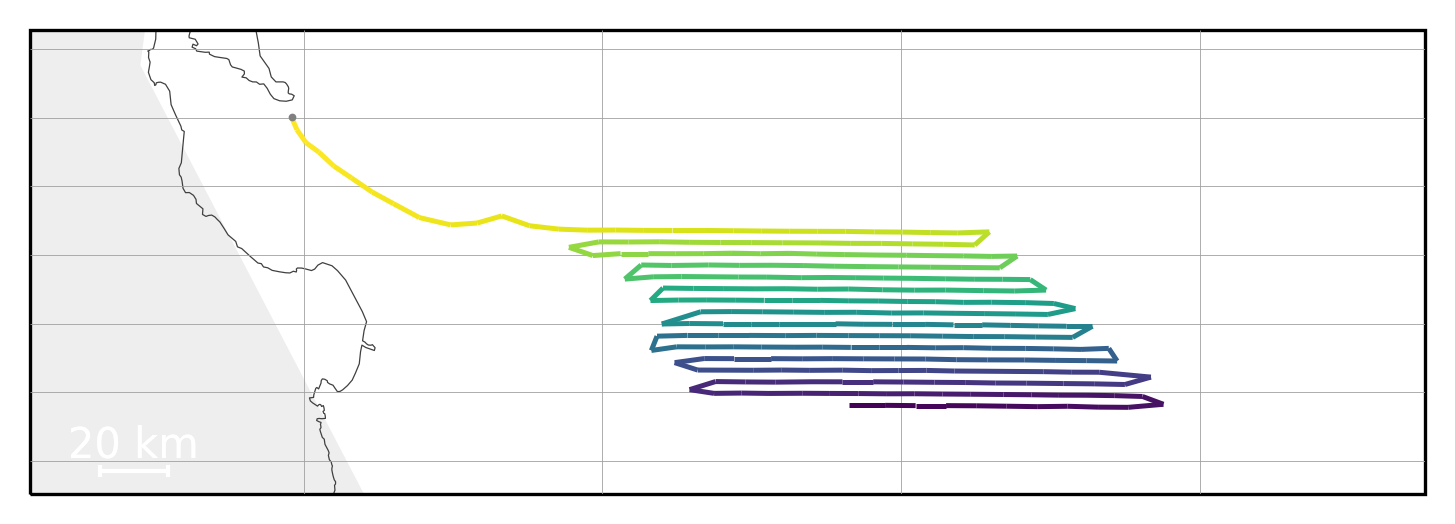

In [6]:
# There are multiple boarders (state and coastlines) that converge at the seashore.  You may want to turn off coastlines
render_trajectories_for_print(all_trajectories[4], "myfig4.pdf", draw_coastlines=False)
#other things you can tweak:
#                     draw_countries=True,
#                     draw_states=True,
#                     fill_land=True,
#                     fill_water=True,
#                     land_fill_color='#101010',
#                     water_fill_color='#000000',
#                     land_zorder=4,
#                     water_zorder=4,
#                     lonlat_spacing=10,
#                     lonlat_color='#A0A0A0',
#                     lonlat_linewidth=0.2,
#                     lonlat_zorder=6,
#                     coastline_color='#808080',
#                     coastline_linewidth=1,
#                     coastline_zorder=5,
#                     country_color='#606060',
#                     country_fill_color='#303030',
#                     country_linewidth=0.5,
#                     country_zorder=3,
#                     state_color='#404040',
#                     state_fill_color='none',
#                     state_linewidth=0.3,
#                     state_zorder=2,
#                     draw_largest_cities=None,
#                     draw_cities_larger_than=None,
#                     city_label_size=12,
#                     city_dot_size=2,
#                     city_dot_color='white',
#                     city_label_color='white',
#                     city_zorder=6,
#                     country_resolution='10m',
#                     state_resolution='10m',
#                     coastline_resolution='50m',
#                     land_resolution='110m',
#                     ocean_resolution='110m',
#                     lake_resolution='110m',
#                     map_bbox=None,
#                     map_projection=None,
#                     map_scale_length=None,
#                     region_size=None

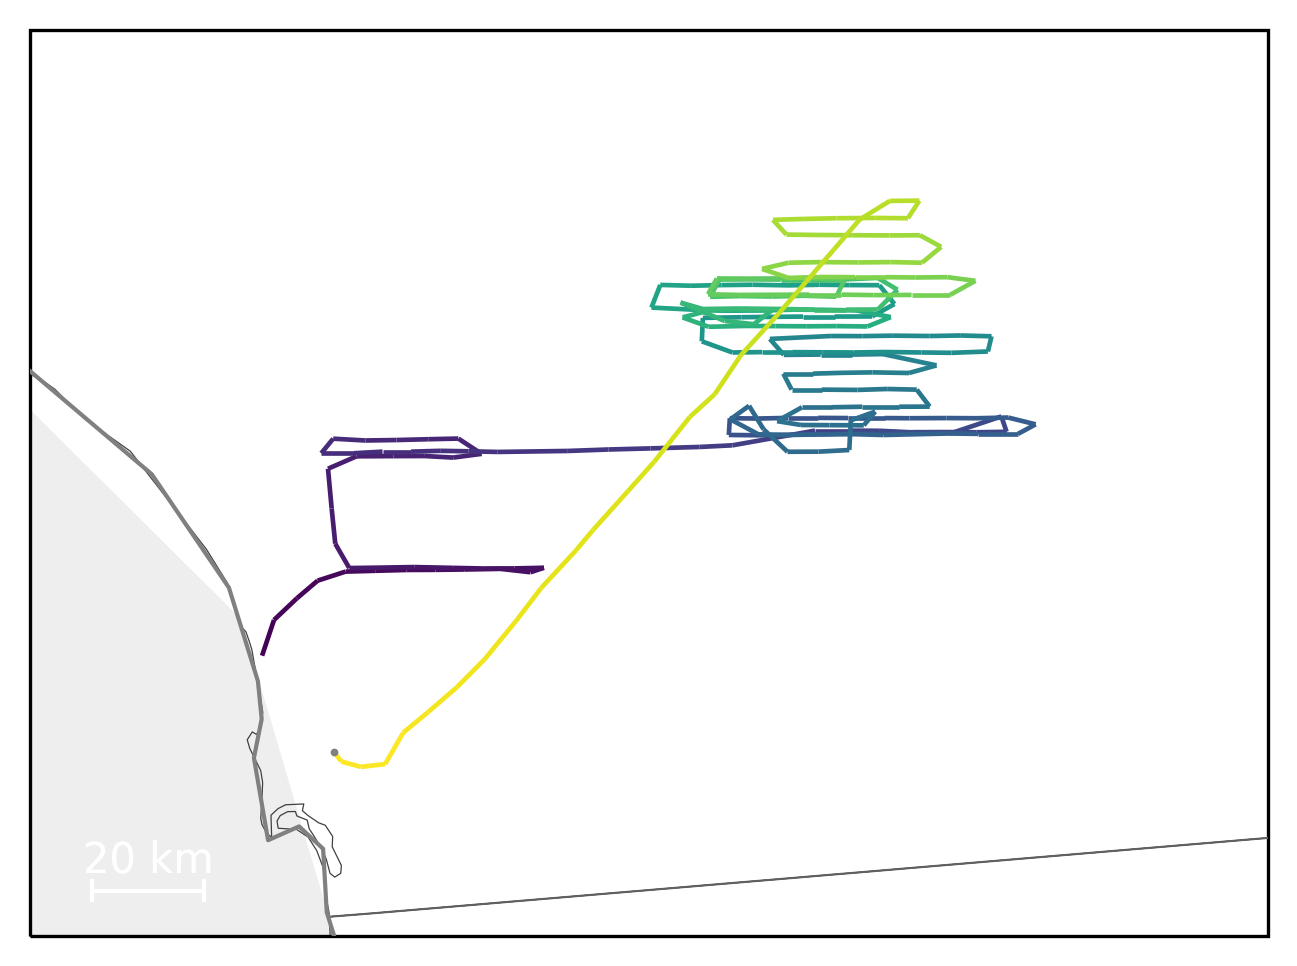

In [7]:
#can turn off Lat/Lon lines
render_trajectories_for_print(all_trajectories[11], "myfig11.pdf", linewidth=1.4, draw_lonlat=False)

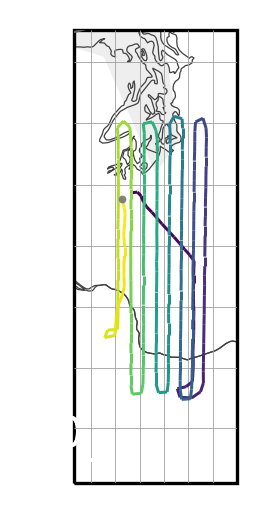

In [8]:
#You can set the size of the figure in inches (width,height) dpi defaults to 300
#unfortunately in this case the map will remain skinny, while the figure will be wide with lots of 
#whitespace on both sides. (you may need to look at the output pdf to see the whitespace.)
render_trajectories_for_print(all_trajectories[13], "myfig13a.pdf", linewidth=.9, figsize=(3,2), draw_coastlines=False)

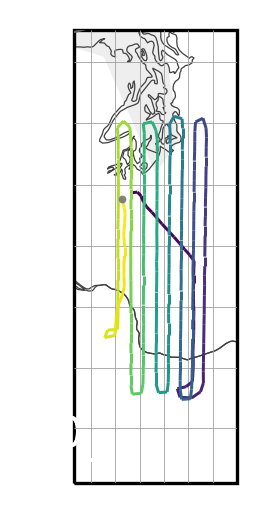

In [9]:
#To fix that extra whitespace (unless you manually crop) you can either adjust the figsize (see pdfs for comparison)
render_trajectories_for_print(all_trajectories[13], "myfig13b.pdf", linewidth=.9, figsize=(1,2), draw_coastlines=False)

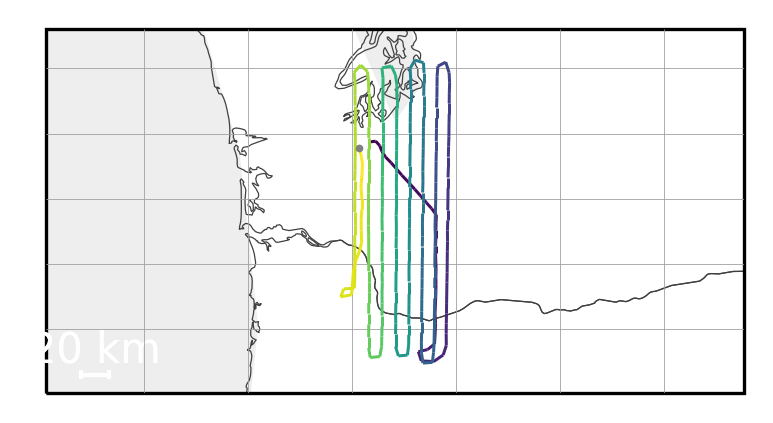

In [10]:
#Or, add extra "bounding box buffer" (width, height) to the map such that more map is shown.  (we hope to automate this at some point)
render_trajectories_for_print(all_trajectories[13], "myfig13c.pdf", linewidth=.9, figsize=(3,2), bbox_buffer=(2.7,.1), draw_coastlines=False)

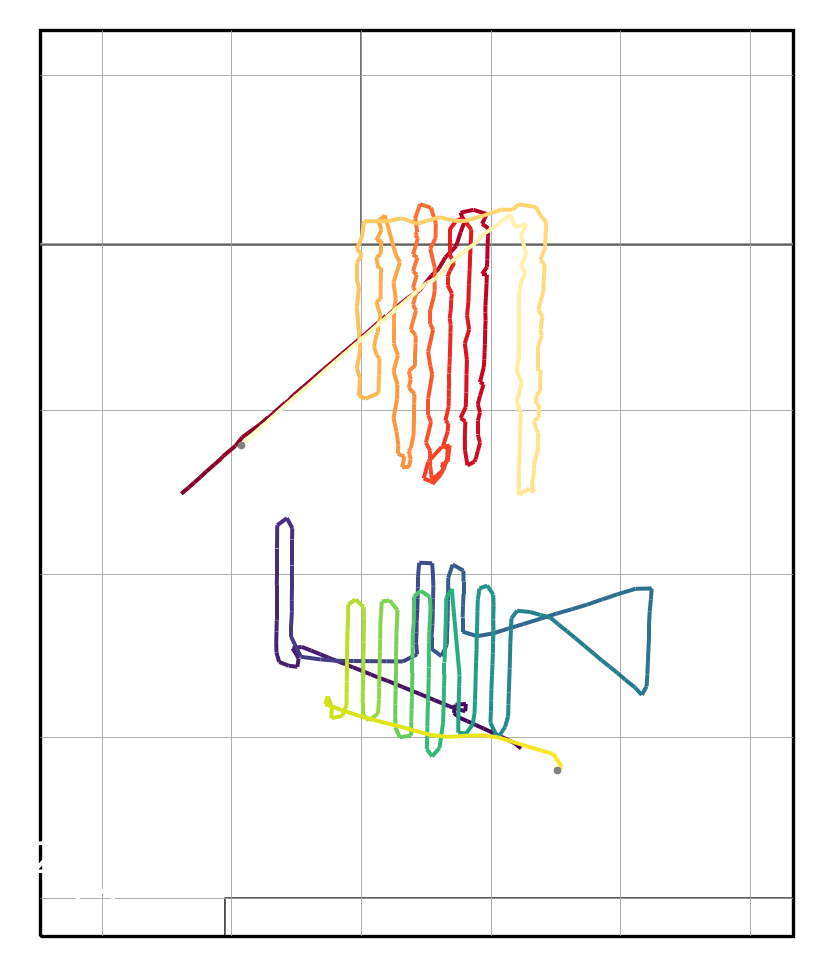

In [11]:
#If you wish to show multiple trajectories with different coloring here are some options:  Multiple color_maps (_r reverses the map)
render_trajectories_for_print(all_trajectories[14:16], "myfig14a.pdf", color_map=['viridis','YlOrRd_r'], linewidth=1.2)

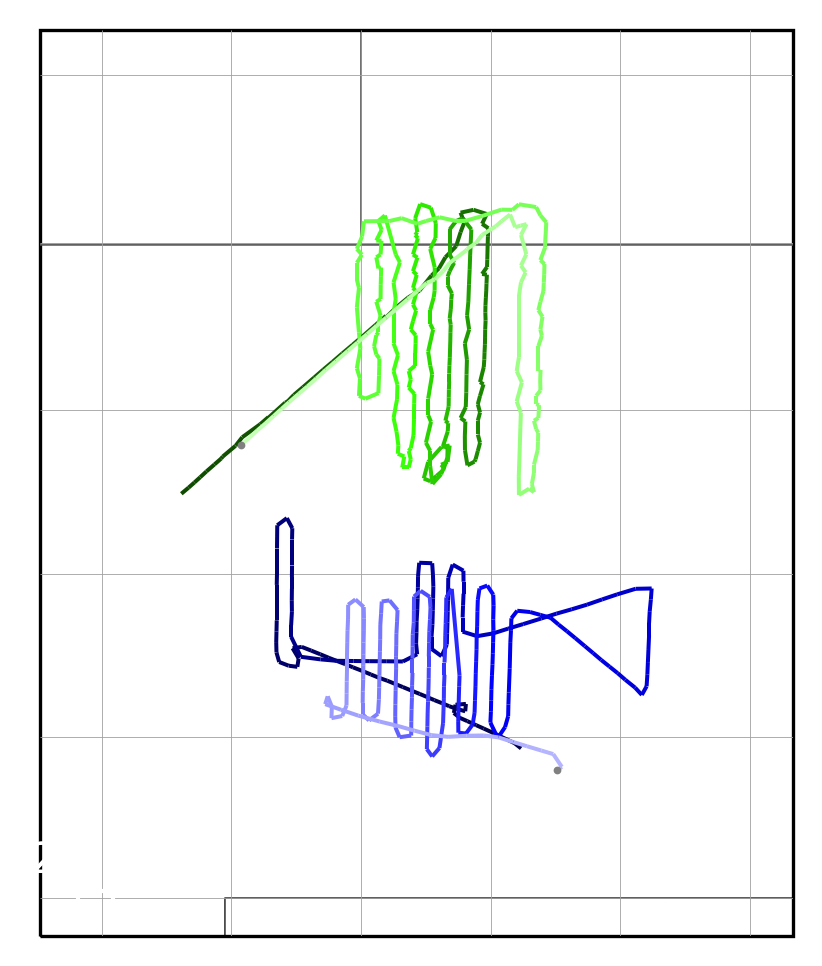

In [12]:
#you may specify the hue for a gradient (dark -> light) using a number (0-1) or a color name or a #RRGGBB color specification (see render_trajectories() for mor info)
render_trajectories_for_print(all_trajectories[14:16], "myfig14b.pdf", gradient_hue=['blue',.3], linewidth=1.2)

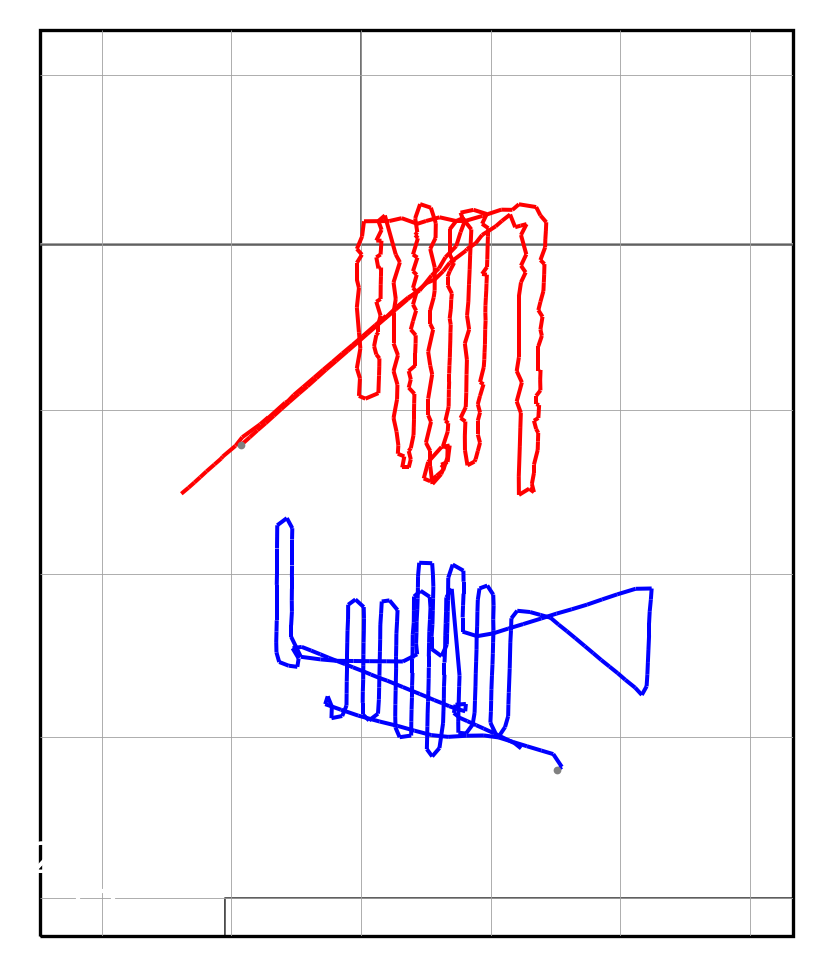

In [13]:
#you may specify a solid color for the lines
render_trajectories_for_print(all_trajectories[14:16], "myfig14c.pdf", line_color=['blue','red'], linewidth=1.2)

/home/mjfadem/.local/lib/python3.8/site-packages/cartopy/mpl/geoaxes.py:834: UserWarning: Attempting to set identical left == right == 180.0 results in singular transformations; automatically expanding.
  self.set_xlim([x1, x2])


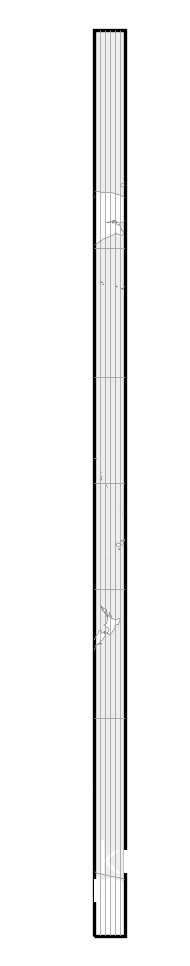

In [14]:
# You can specify a specific bounding box.  In this case entire world.
render_trajectories_for_print(all_trajectories[15:25], "myfig15a.pdf", map_bbox=[-180,-90,180,90], linewidth=.3, coastline_linewidth=.15, draw_countries=False, draw_states=False, dot_size=.05)

/home/mjfadem/.local/lib/python3.8/site-packages/cartopy/mpl/geoaxes.py:834: UserWarning: Attempting to set identical left == right == 180.0 results in singular transformations; automatically expanding.
  self.set_xlim([x1, x2])


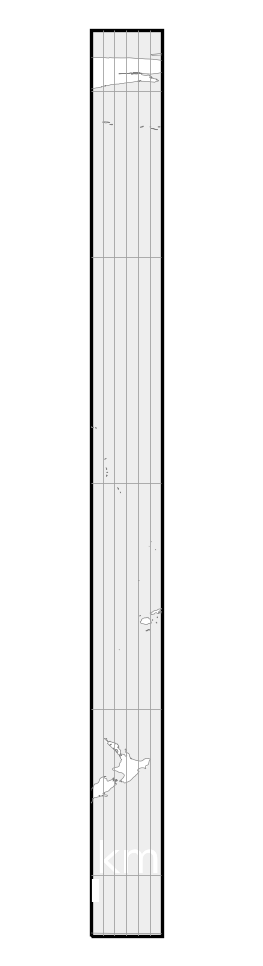

In [15]:
#You can specify a projection (LambertCylindrical)
# See options here: https://scitools.org.uk/cartopy/docs/latest/crs/projections.html
render_trajectories_for_print(all_trajectories[15:25], "myfig15b.pdf", map_projection=cartopy.crs.LambertCylindrical, map_bbox=[-180,-90,180,90], linewidth=.3, coastline_linewidth=.15, draw_countries=False, draw_states=False, dot_size=.05)

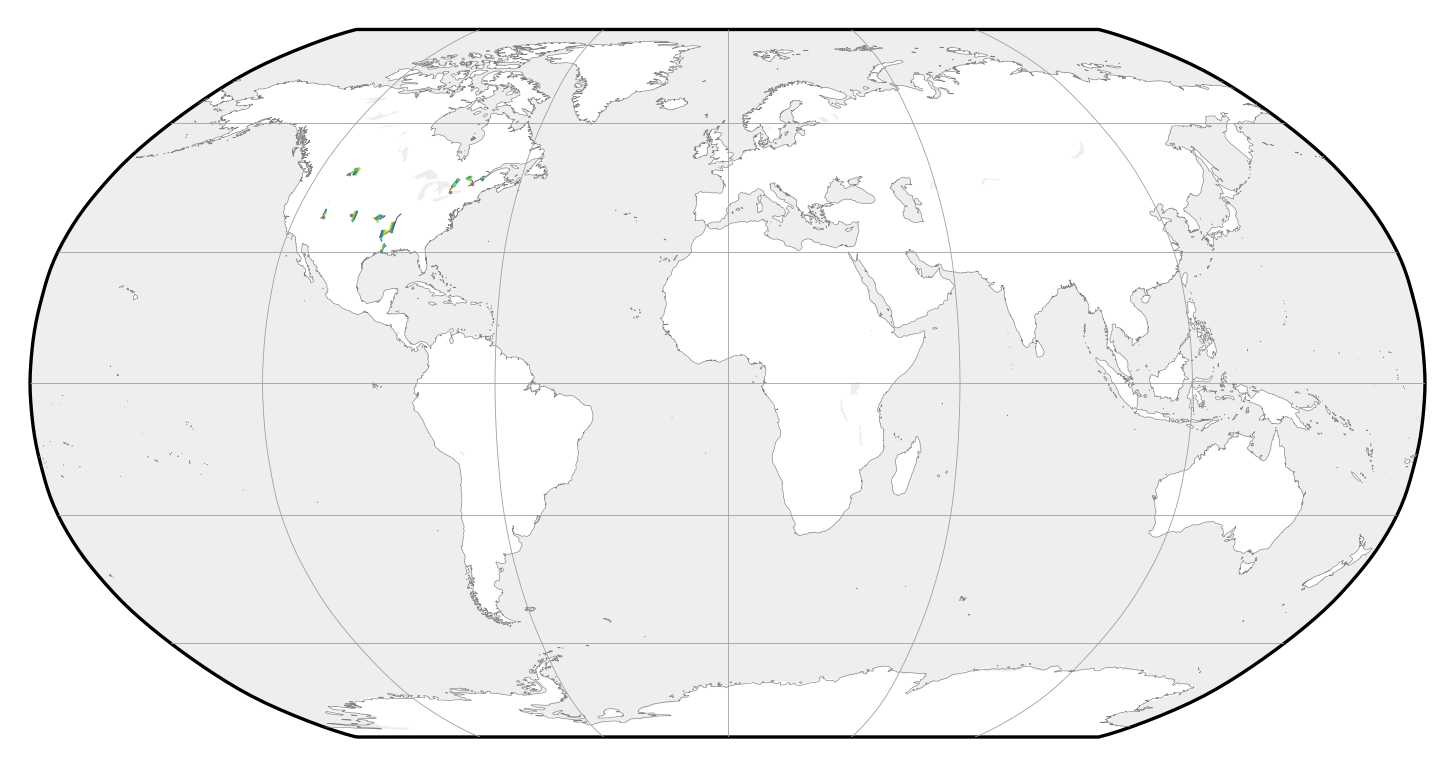

In [16]:
#if using a "global" projection and you want to see all of it, set map_global=True to use the limites of the projection
render_trajectories_for_print(all_trajectories[15:25], "myfig15c.pdf", map_global=True, map_projection=cartopy.crs.Robinson, linewidth=.3, coastline_linewidth=.15, draw_countries=False, draw_states=False, dot_size=.05)

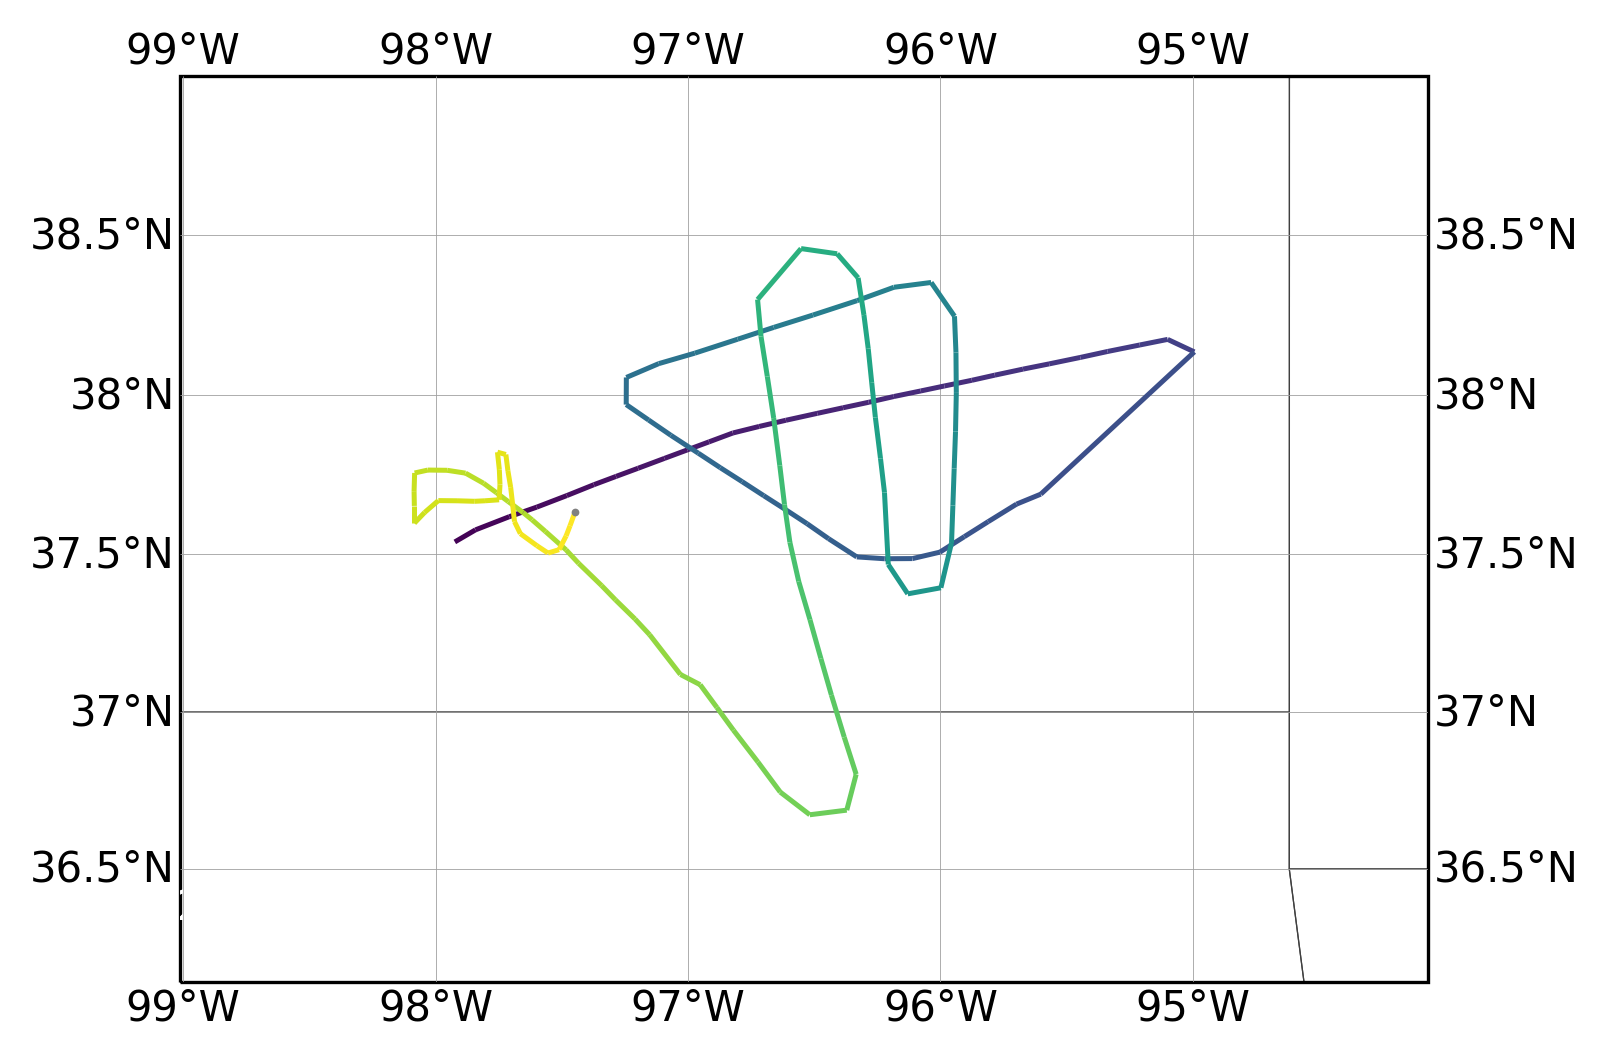

In [17]:
# You can add labels for lon/lat, only with certain projections.
# Only PlateCarree and Mercator plots currently support drawing labels for lon/lats.  
#Recommended projection (Miller) does not support automatically drawing labels.
render_trajectories_for_print(all_trajectories[17], "myfig17.pdf", lonlat_labels=True, map_projection=cartopy.crs.Mercator)

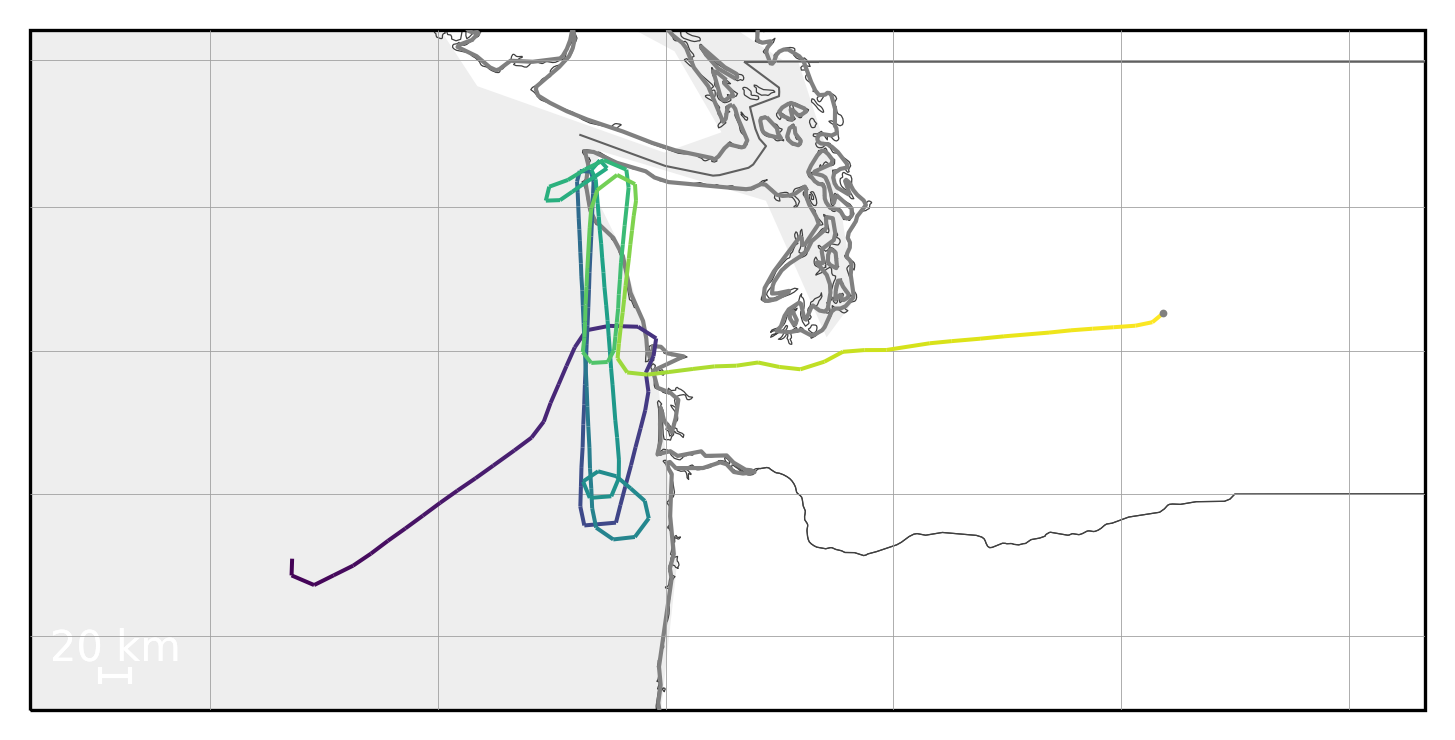

In [18]:
# The border resolution can be adjusted. (Low res)
#110m = low res, 50m = med res, 10m high res
render_trajectories_for_print(all_trajectories[25], "myfig25a.pdf", linewidth=1.2, border_resolution='110m') 

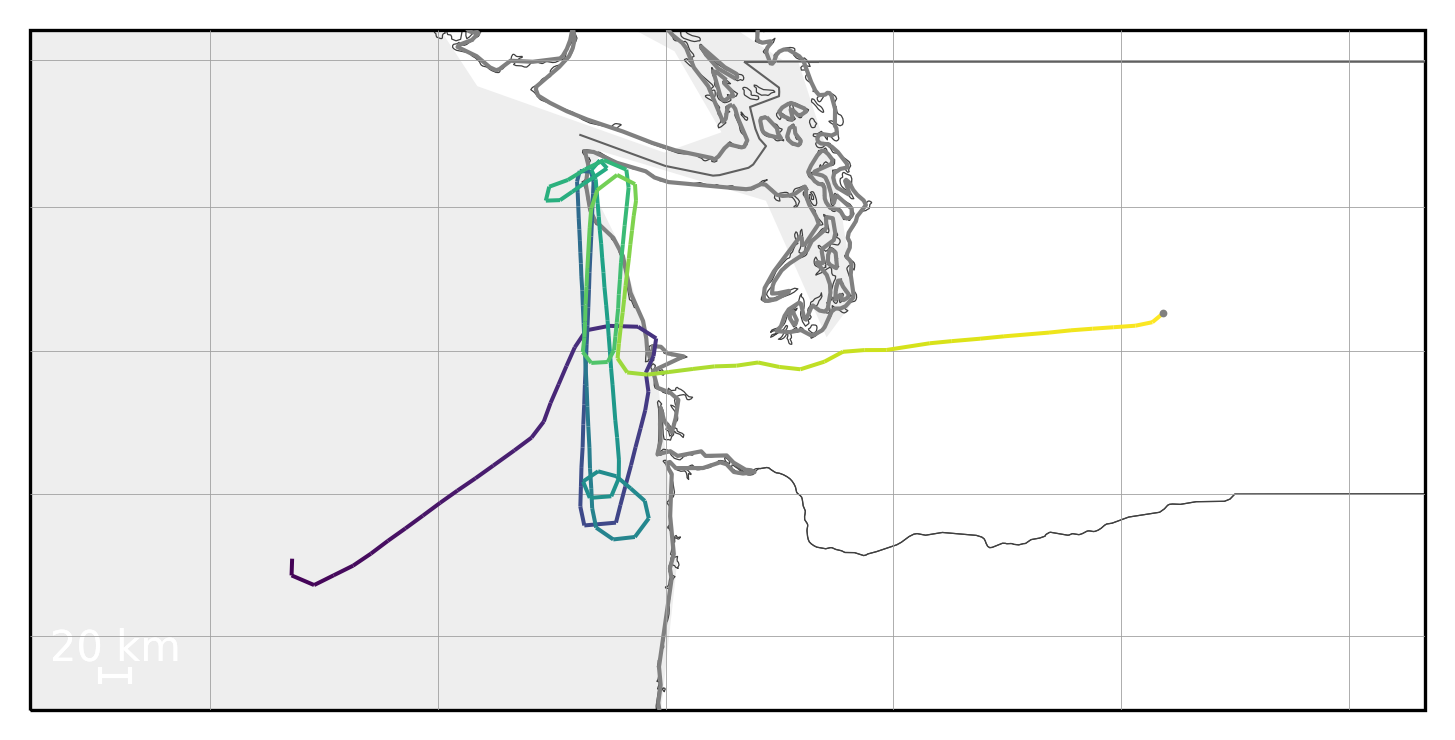

In [19]:
# The border resolution can be adjusted. (High res)
render_trajectories_for_print(all_trajectories[25], "myfig25b.pdf", linewidth=1.2, border_resolution='10m')

<urlopen error EOF occurred in violation of protocol (_ssl.c:1131)>
<urlopen error EOF occurred in violation of protocol (_ssl.c:1131)>
<urlopen error EOF occurred in violation of protocol (_ssl.c:1131)><urlopen error EOF occurred in violation of protocol (_ssl.c:1131)>

<urlopen error EOF occurred in violation of protocol (_ssl.c:1131)>
<urlopen error EOF occurred in violation of protocol (_ssl.c:1131)><urlopen error EOF occurred in violation of protocol (_ssl.c:1131)>
<urlopen error EOF occurred in violation of protocol (_ssl.c:1131)>

<urlopen error EOF occurred in violation of protocol (_ssl.c:1131)><urlopen error EOF occurred in violation of protocol (_ssl.c:1131)>

<urlopen error EOF occurred in violation of protocol (_ssl.c:1131)>
<urlopen error EOF occurred in violation of protocol (_ssl.c:1131)>
<urlopen error EOF occurred in violation of protocol (_ssl.c:1131)><urlopen error EOF occurred in violation of protocol (_ssl.c:1131)>

<urlopen error EOF occurred in violation of prot

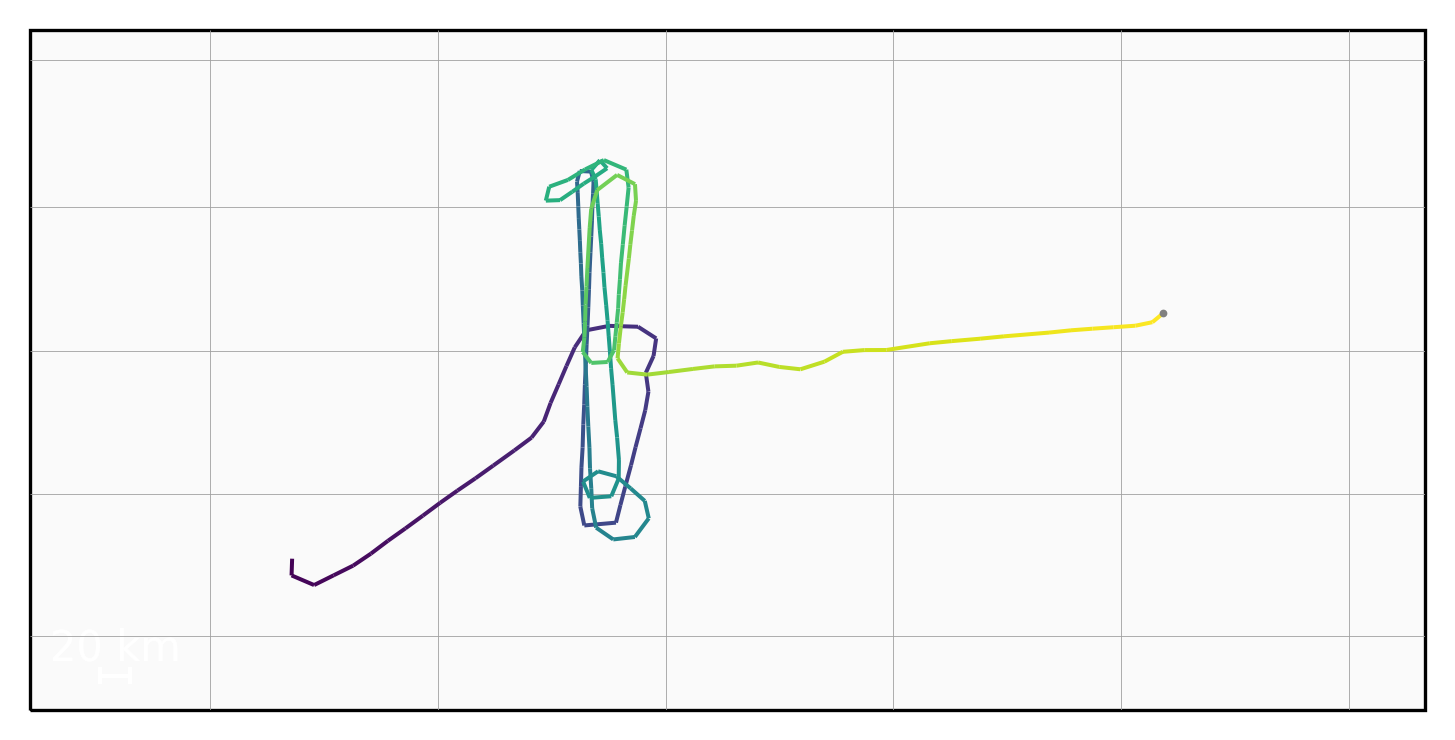

In [20]:
#using this method you can use map tiles instead of Cartopy geometry.  
render_trajectories_for_print_using_tiles(all_trajectories[25], "myfig25c.pdf", linewidth=1.2)

<urlopen error EOF occurred in violation of protocol (_ssl.c:1131)>


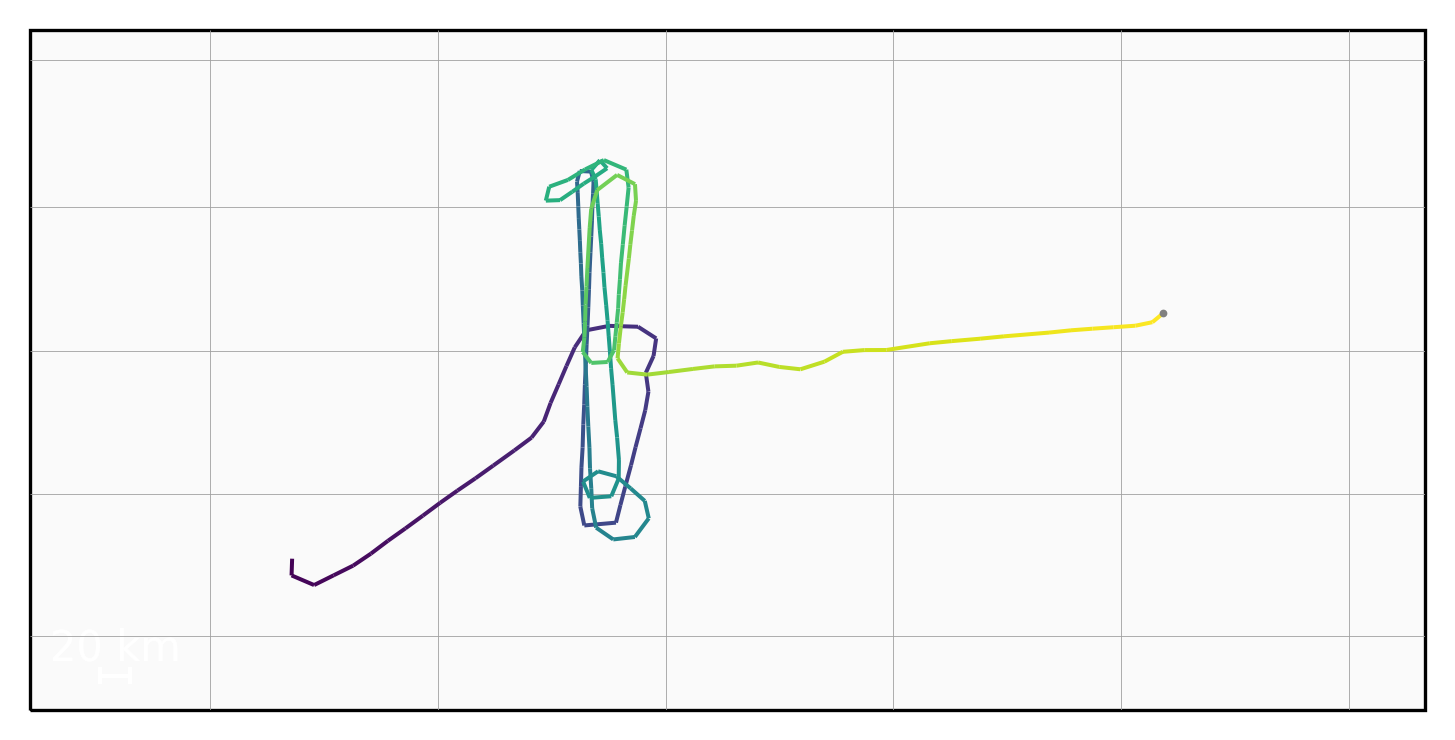

In [21]:
# You can change the zoom level 
render_trajectories_for_print_using_tiles(all_trajectories[25], "myfig25d.pdf", linewidth=1.2, tiles_zoom_level=2)

<urlopen error EOF occurred in violation of protocol (_ssl.c:1131)>
<urlopen error EOF occurred in violation of protocol (_ssl.c:1131)><urlopen error EOF occurred in violation of protocol (_ssl.c:1131)><urlopen error EOF occurred in violation of protocol (_ssl.c:1131)>

<urlopen error EOF occurred in violation of protocol (_ssl.c:1131)>

<urlopen error EOF occurred in violation of protocol (_ssl.c:1131)><urlopen error EOF occurred in violation of protocol (_ssl.c:1131)>

<urlopen error EOF occurred in violation of protocol (_ssl.c:1131)><urlopen error EOF occurred in violation of protocol (_ssl.c:1131)><urlopen error EOF occurred in violation of protocol (_ssl.c:1131)><urlopen error EOF occurred in violation of protocol (_ssl.c:1131)><urlopen error EOF occurred in violation of protocol (_ssl.c:1131)>
<urlopen error EOF occurred in violation of protocol (_ssl.c:1131)><urlopen error EOF occurred in violation of protocol (_ssl.c:1131)><urlopen error EOF occurred in violation of protocol (

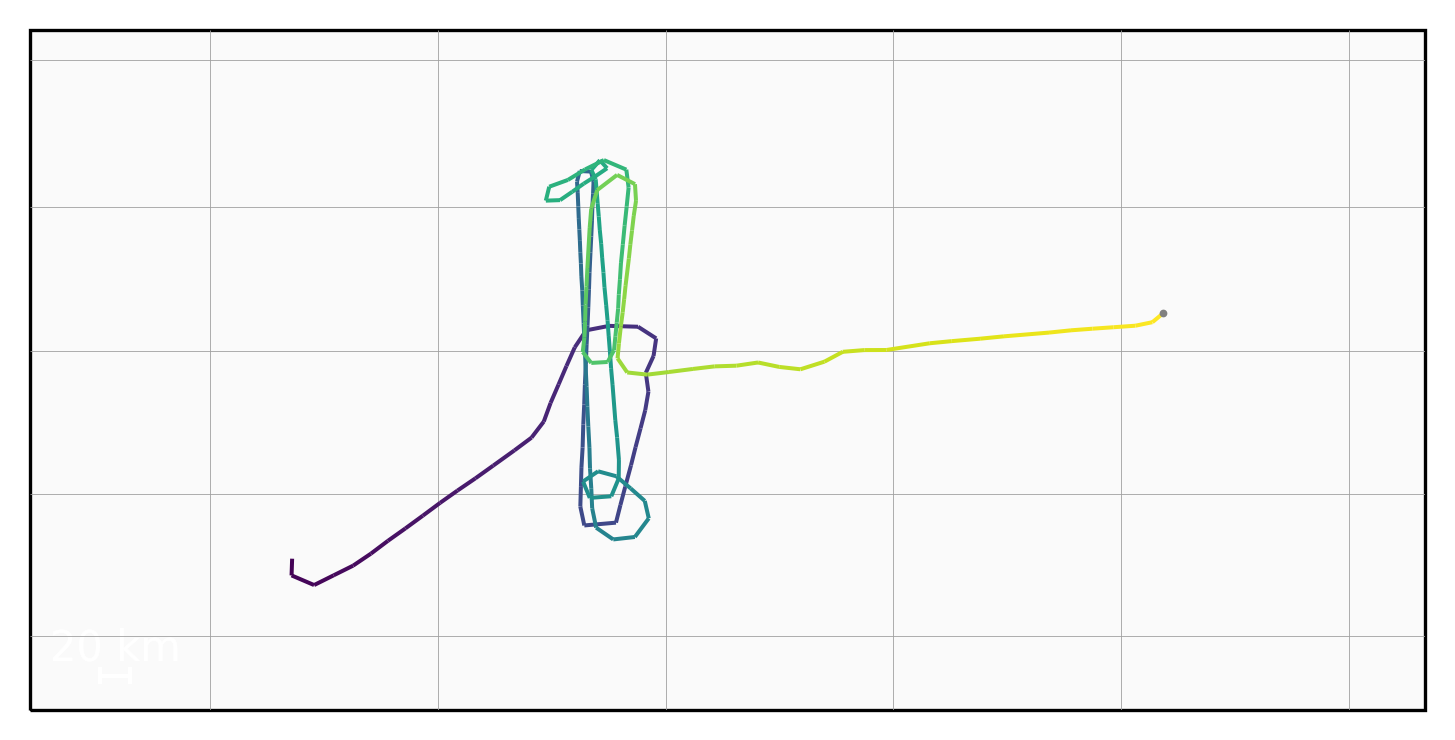

In [22]:
# And should adjust the zoom level until the label font is correclty sized. 
render_trajectories_for_print_using_tiles(all_trajectories[25], "myfig25e.pdf", linewidth=1.2, tiles_zoom_level=7)